# 01 &mdash; Rolling-Window Backtest on Raw Prices

This notebook is the starting point of the benchmark. We follow the same
order the research actually happened:

1. Load 32 years of daily ICE Coffee C futures closes and visualize the
   price series.
2. Assemble the 10-model suite (5 categories).
3. **Snapshot: a single forecast** &mdash; run each model once on the final
   63-day holdout window to confirm they all produce sensible paths
   before committing to the expensive multi-origin backtest.
4. Visualize where the 1 / 10 / 30 / 60 forecast origins will sit on
   the price series.
5. Run the rolling-window backtest at all four scales.
6. Export the two CSVs that every downstream notebook consumes:

| File | Rows | Purpose |
|---|---|---|
| `results/csv/summary_all_scales.csv` | `101 x 10 = 1010` | One row per (origin, model); MAE / RMSE / MAPE / sMAPE / MASE |
| `results/csv/step_errors_all_scales.csv` | `~63,630` | One row per (scale, model, origin, step); absolute error at each forecast step |

The step-errors table is the input to the Diebold-Mariano test and the Model
Confidence Set in notebook 03.

## Backtest design

- **Context window:** 1,536 trading days ($\approx$ 6 years)
- **Horizon:** 63 trading days ($\approx$ 3 months)
- **Scales:** 1, 10, 30, 60 evenly-spaced forecast origins
- No model sees test data during fitting; every origin gets a fresh fit on
  the preceding 1,536 days.


## 1. Environment setup

In [27]:
import logging
import sys
from pathlib import Path

# Let the notebook import the sibling `coffee_forecast` package
# without requiring `pip install -e .`.
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Mute the noisiest third-party libraries.
for name in ("cmdstanpy", "prophet", "statsforecast"):
    logging.getLogger(name).setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

from coffee_forecast import (
    load_coffee_data,
    run_multi_scale_backtest,
    StatsForecastWrapper,
    GARCHWrapper,
    ProphetWrapper,
    MLRecursiveWrapper,
    GraniteWrapper,
)
from coffee_forecast.backtest import step_errors_to_long_df
from coffee_forecast.config import (
    CONTEXT_LEN,
    HORIZON,
    SCALES,
    SEED,
    CSV_DIR,
    FIG_DIR,
)
from coffee_forecast.viz import plot_price_series, plot_forecast_origin_coverage

# Ensure output directories exist.
CSV_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the price series

`load_coffee_data` returns a tidy frame with `ds` (datetime), `y` (cents/lb),
and `unique_id` (required by `statsforecast`). Non-numeric rows are dropped
and dates are normalized so downstream arithmetic never trips on timestamps.

In [28]:
df = load_coffee_data()
print(
    f"Loaded {len(df)} trading days ({df['ds'].min().date()} → {df['ds'].max().date()})"
)
df.head()

Loaded 8104 trading days (1994-01-03 → 2026-01-30)


,ds,y,unique_id
0,1994-01-03,72.50,coffee
1,1994-01-04,71.85,coffee
2,1994-01-05,71.55,coffee
3,1994-01-06,72.10,coffee
4,1994-01-07,72.50,coffee


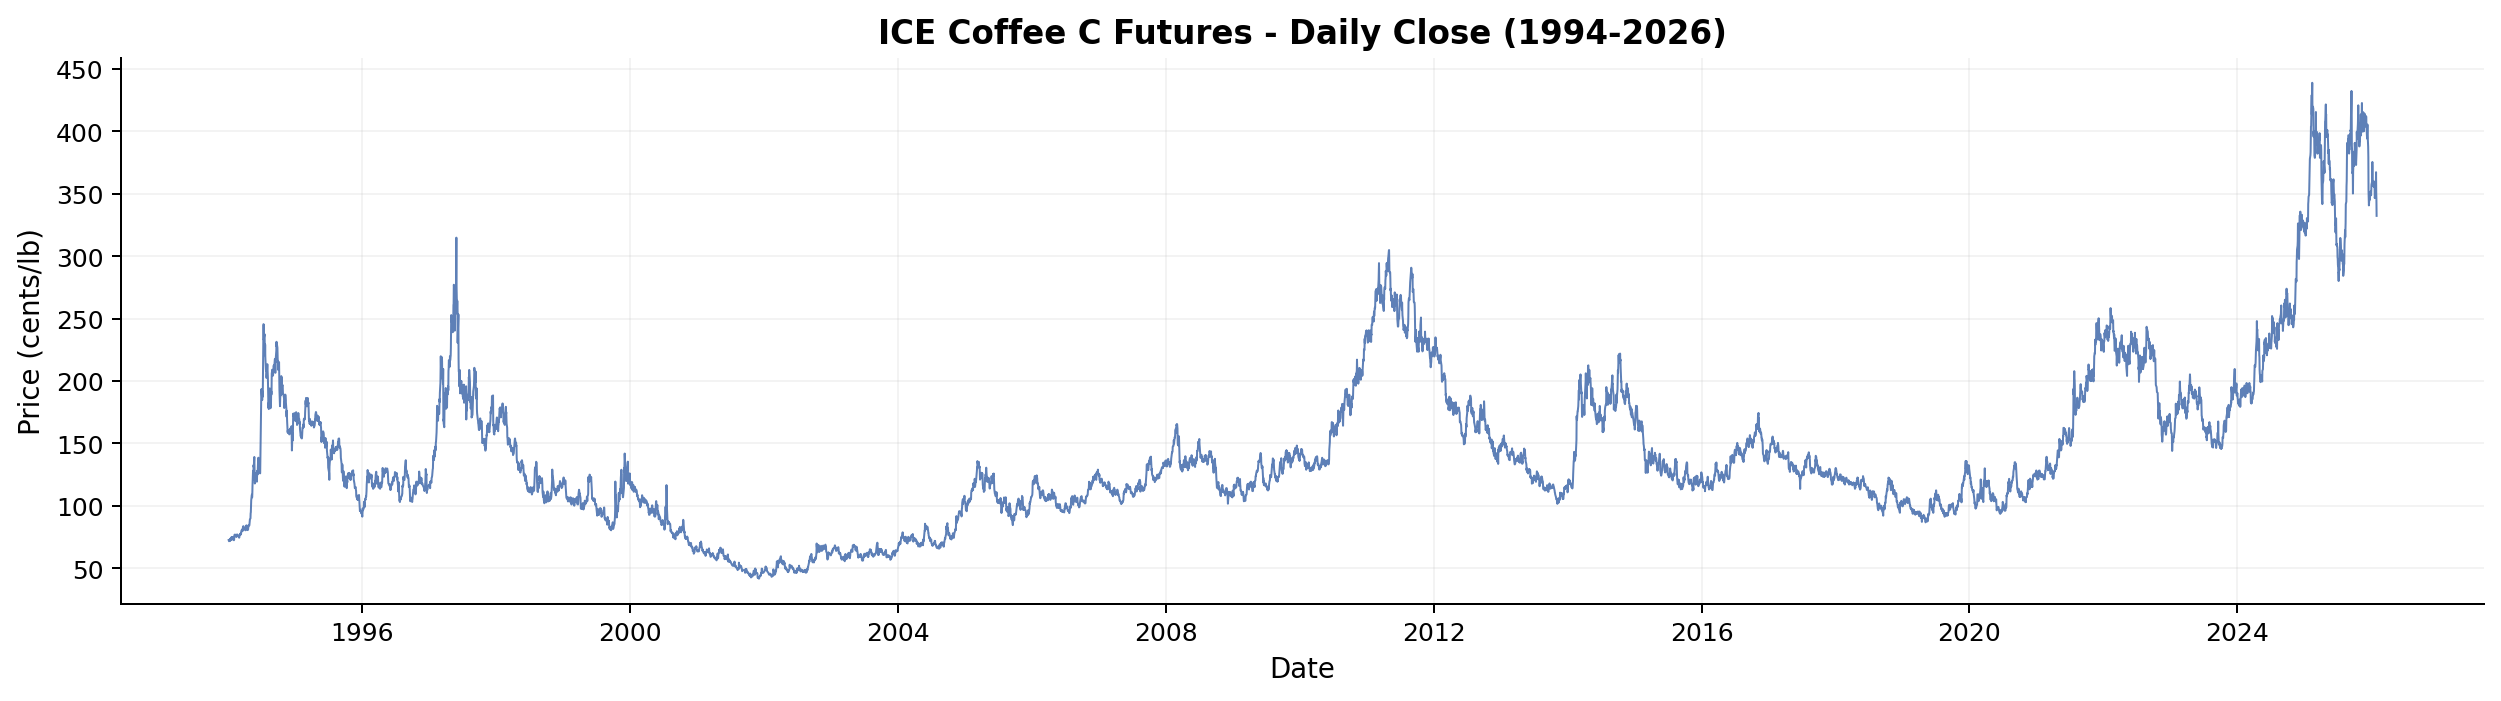

In [29]:
_ = plot_price_series(df, save_path=FIG_DIR / "price_series.png")
plt.show()

## 3. Assemble the 10-model suite

Every wrapper exposes a uniform `predict(context_df, horizon) -> ndarray`
interface, so the backtest runner treats them all identically.

| Category | Models |
|---|---|
| Simple baselines | Naive, RWD (random walk with drift), Theta |
| Classical statistical | ETS (AutoETS), ARIMA (AutoARIMA) |
| Volatility | GARCH(1,1) with AR(1) mean |
| Structural decomposition | Prophet |
| Recursive ML | Ridge, Random Forest (lag + rolling features) |
| Foundation (zero-shot) | IBM Granite TTM |


In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsforecast.models import (
    AutoARIMA,
    AutoETS,
    Naive,
    RandomWalkWithDrift,
    Theta,
)
from tsfm_public.toolkit.get_model import get_model

device = "cuda" if torch.cuda.is_available() else "cpu"

ttm = (
    get_model(
        model_path="ibm-granite/granite-timeseries-ttm-r2",
        model_name="ttm",
        context_length=CONTEXT_LEN,
        prediction_length=96,  # must be >= HORIZON = 63
        prefer_longer_context=True,
        return_model_key=False,
    )
    .to(device)
    .eval()
)
print(f"IBM Granite TTM loaded on {device.upper()}")

models = {
    # Simple baselines
    "Naive": StatsForecastWrapper(Naive(alias="Naive")),
    "RWD": StatsForecastWrapper(RandomWalkWithDrift(alias="RWD")),
    "Theta": StatsForecastWrapper(Theta(season_length=252, alias="Theta")),
    # Classical
    "ETS": StatsForecastWrapper(AutoETS(alias="ETS")),
    "ARIMA": StatsForecastWrapper(AutoARIMA(seasonal=False, alias="ARIMA")),
    # Volatility
    "GARCH": GARCHWrapper(),
    # Structural decomposition
    "Prophet": ProphetWrapper(),
    # Recursive ML
    "Ridge": MLRecursiveWrapper(make_pipeline(StandardScaler(), Ridge())),
    "RF": MLRecursiveWrapper(
        RandomForestRegressor(n_estimators=100, random_state=SEED)
    ),
    # Foundation model
    "Granite-TTM": GraniteWrapper(ttm, device, context_len=CONTEXT_LEN),
}
print(f"{len(models)} models initialized across 5 categories.")

INFO:p-56046:t-8514574528:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-56046:t-8514574528:get_model.py:get_model:Model path type is 2
INFO:p-56046:t-8514574528:get_model.py:get_model:Attempting model load from ibm-granite/granite-timeseries-ttm-r2, revision = 1536-96-r2.
INFO:p-56046:t-8514574528:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 1536-96-r2.
INFO:p-56046:t-8514574528:get_model.py:get_model:[TTM] context_length = 1536, prediction_length = 96


IBM Granite TTM loaded on CPU
10 models initialized across 5 categories.


## 4. Snapshot: a single forecast

The first thing we did &mdash; before committing to any multi-origin
benchmark &mdash; was to run each of the ten models on a single 63-day
holdout window and look at the paths. The question was
*"are the models even producing sensible forecasts?"*, not *"who
wins?"*. Runtime here is several minutes, dominated by Granite-TTM
inference and Prophet's Stan compilation.


In [31]:
from coffee_forecast import calculate_metrics
from coffee_forecast.config import COLOR_MAP, PLOT_ORDER

# The final 63 trading days are the holdout; the preceding CONTEXT_LEN
# days are the context each model sees.
a = len(df) - HORIZON
context_df = df.iloc[a - CONTEXT_LEN : a].copy()
test_df = df.iloc[a : a + HORIZON].copy()
y_true = test_df["y"].to_numpy(dtype=float)
train_y = context_df["y"].to_numpy(dtype=float)
test_start = test_df["ds"].iloc[0]

# Generate forecasts.
plot_df = pd.DataFrame({"ds": test_df["ds"].to_numpy(), "Actual": y_true})
for name, wrapper in models.items():
    try:
        plot_df[name] = wrapper.predict(context_df, HORIZON)
        print(f"  ok  {name}")
    except Exception as e:
        print(f"  ERR {name}: {e}")

# Single-origin metrics, sorted by MAE.
rows = []
for name in PLOT_ORDER:
    if name not in plot_df.columns:
        continue
    y_hat = plot_df[name].to_numpy(dtype=float)
    if np.any(~np.isfinite(y_hat)):
        continue
    metrics = calculate_metrics(y_true, y_hat, train_y)
    metrics["Model"] = name
    rows.append(metrics)

holdout_metrics = (
    pd.DataFrame(rows)
    .sort_values("MAE")
    .reset_index(drop=True)[["Model", "MAE", "RMSE", "sMAPE", "MASE"]]
)
holdout_metrics.to_csv(CSV_DIR / "single_origin_metrics.csv", index=False)
print("\nSaved: results/csv/single_origin_metrics.csv")
holdout_metrics.round(3)


  ok  Naive
  ok  RWD
  ok  Theta
  ok  ETS
  ok  ARIMA
  ok  GARCH
  ok  Prophet
  ok  Ridge
  ok  RF
  ok  Granite-TTM

Saved: results/csv/single_origin_metrics.csv


,Model,MAE,RMSE,sMAPE,MASE
0,Granite-TTM,20.875,22.601,0.055,5.781
1,GARCH,23.348,25.852,0.062,6.466
2,RF,24.552,26.087,0.065,6.800
3,Ridge,24.709,29.209,0.065,6.843
4,ETS,26.039,29.876,0.069,7.212
5,Naive,26.039,29.876,0.069,7.212
6,ARIMA,26.044,29.927,0.069,7.213
7,Theta,27.325,31.971,0.072,7.568
8,RWD,29.231,35.043,0.077,8.096
9,Prophet,49.243,60.306,0.124,13.638


Note this is a single-window snapshot &mdash; the ranking here does not generalize. The multi-origin backtest in §6 gives the aggregate result, and RWD (worst on this window) emerges as the mean-MAE leader across 60 origins.

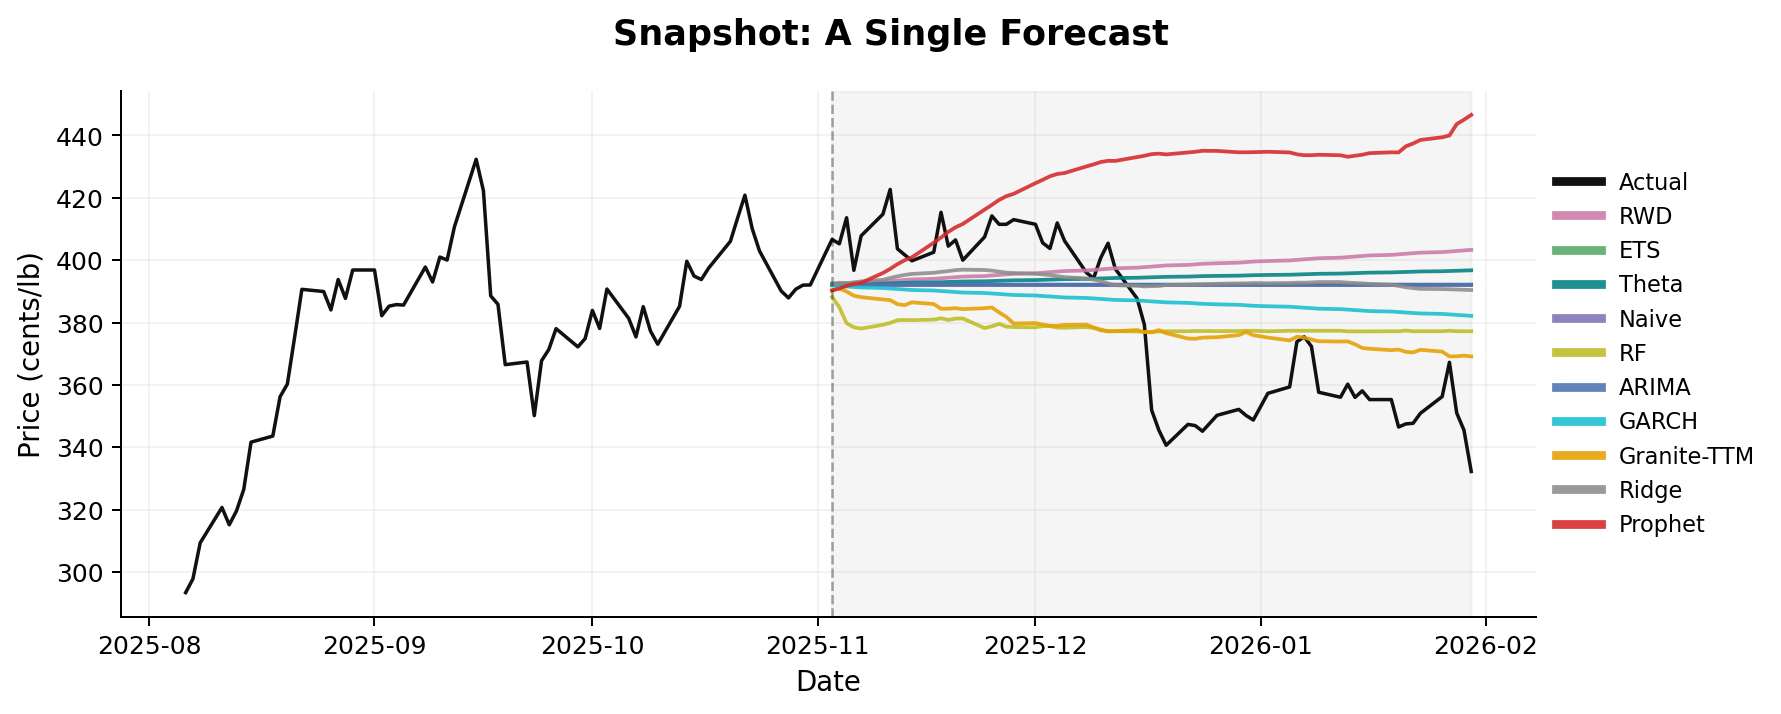

In [32]:
# Show the last 63 trading days *before* the holdout too so the forecast
# isn't floating in space.
VIS_DAYS = HORIZON
vis_start = max(0, a - VIS_DAYS)
vis_df = df.iloc[vis_start : a + HORIZON][["ds", "y"]].copy()

fig, ax = plt.subplots(figsize=(10, 4), dpi=180)

ax.axvspan(test_start, vis_df["ds"].max(), color="gray", alpha=0.08)
ax.plot(
    vis_df["ds"], vis_df["y"], color=COLOR_MAP["Actual"], linewidth=1.4, label="Actual"
)

for name in PLOT_ORDER:
    if name not in plot_df.columns:
        continue
    y_hat = plot_df[name].to_numpy(dtype=float)
    if np.any(~np.isfinite(y_hat)):
        continue
    ax.plot(
        plot_df["ds"],
        y_hat,
        color=COLOR_MAP.get(name, "#666666"),
        linewidth=1.5,
        alpha=0.88,
        label=name,
    )

ax.axvline(test_start, ls="--", linewidth=1, color="black", alpha=0.35)

fig.suptitle("Snapshot: A Single Forecast", fontsize=14, weight="semibold", y=0.98)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (cents/lb)", fontsize=11)
ax.grid(True, alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9)
for line in leg.get_lines():
    line.set_linewidth(3.5)

fig.tight_layout()
fig.savefig(FIG_DIR / "coffee_holdout_plot.png", dpi=300, bbox_inches="tight")
plt.show()


**Reading this plot.** Each model's 63-day forecast, overlaid with
the realized path:

- **Naive, ETS, ARIMA** forecast a nearly flat line at the last
  observed price &mdash; the behavior expected under a near-random-walk
  prior. RWD adds a small drift term, which on this window tracks
  the early part of the realized path.
- **Granite-TTM** produces a smoothly curving forecast with gentle
  mean reversion, a pattern shaped by its pretraining distribution.
- **Prophet** extrapolates the recent upward trend aggressively,
  projecting the price well above the realized path.
- **GARCH** produces a conservative mean forecast with small
  variation.

Visually, everything looks sensible. The simple baselines cluster
near the last observation; the more flexible models (Prophet,
Granite-TTM) make stronger claims. With that sanity check behind
us we moved to the main question: whether those differences are
real, which needs many origins rather than one window.


## 5. Visualize where the forecast origins sit

With the sanity check passed, we plan the benchmark itself. Running one
origin could be cherry-picked; we need multiple origins spread across
the series. We landed on four scales &mdash; 1, 10, 30, 60 &mdash; and
the plot below shows where each set of origins falls relative to the
price history, including the 1997 spike, the 2011 peak, and the
2024-2025 surge.


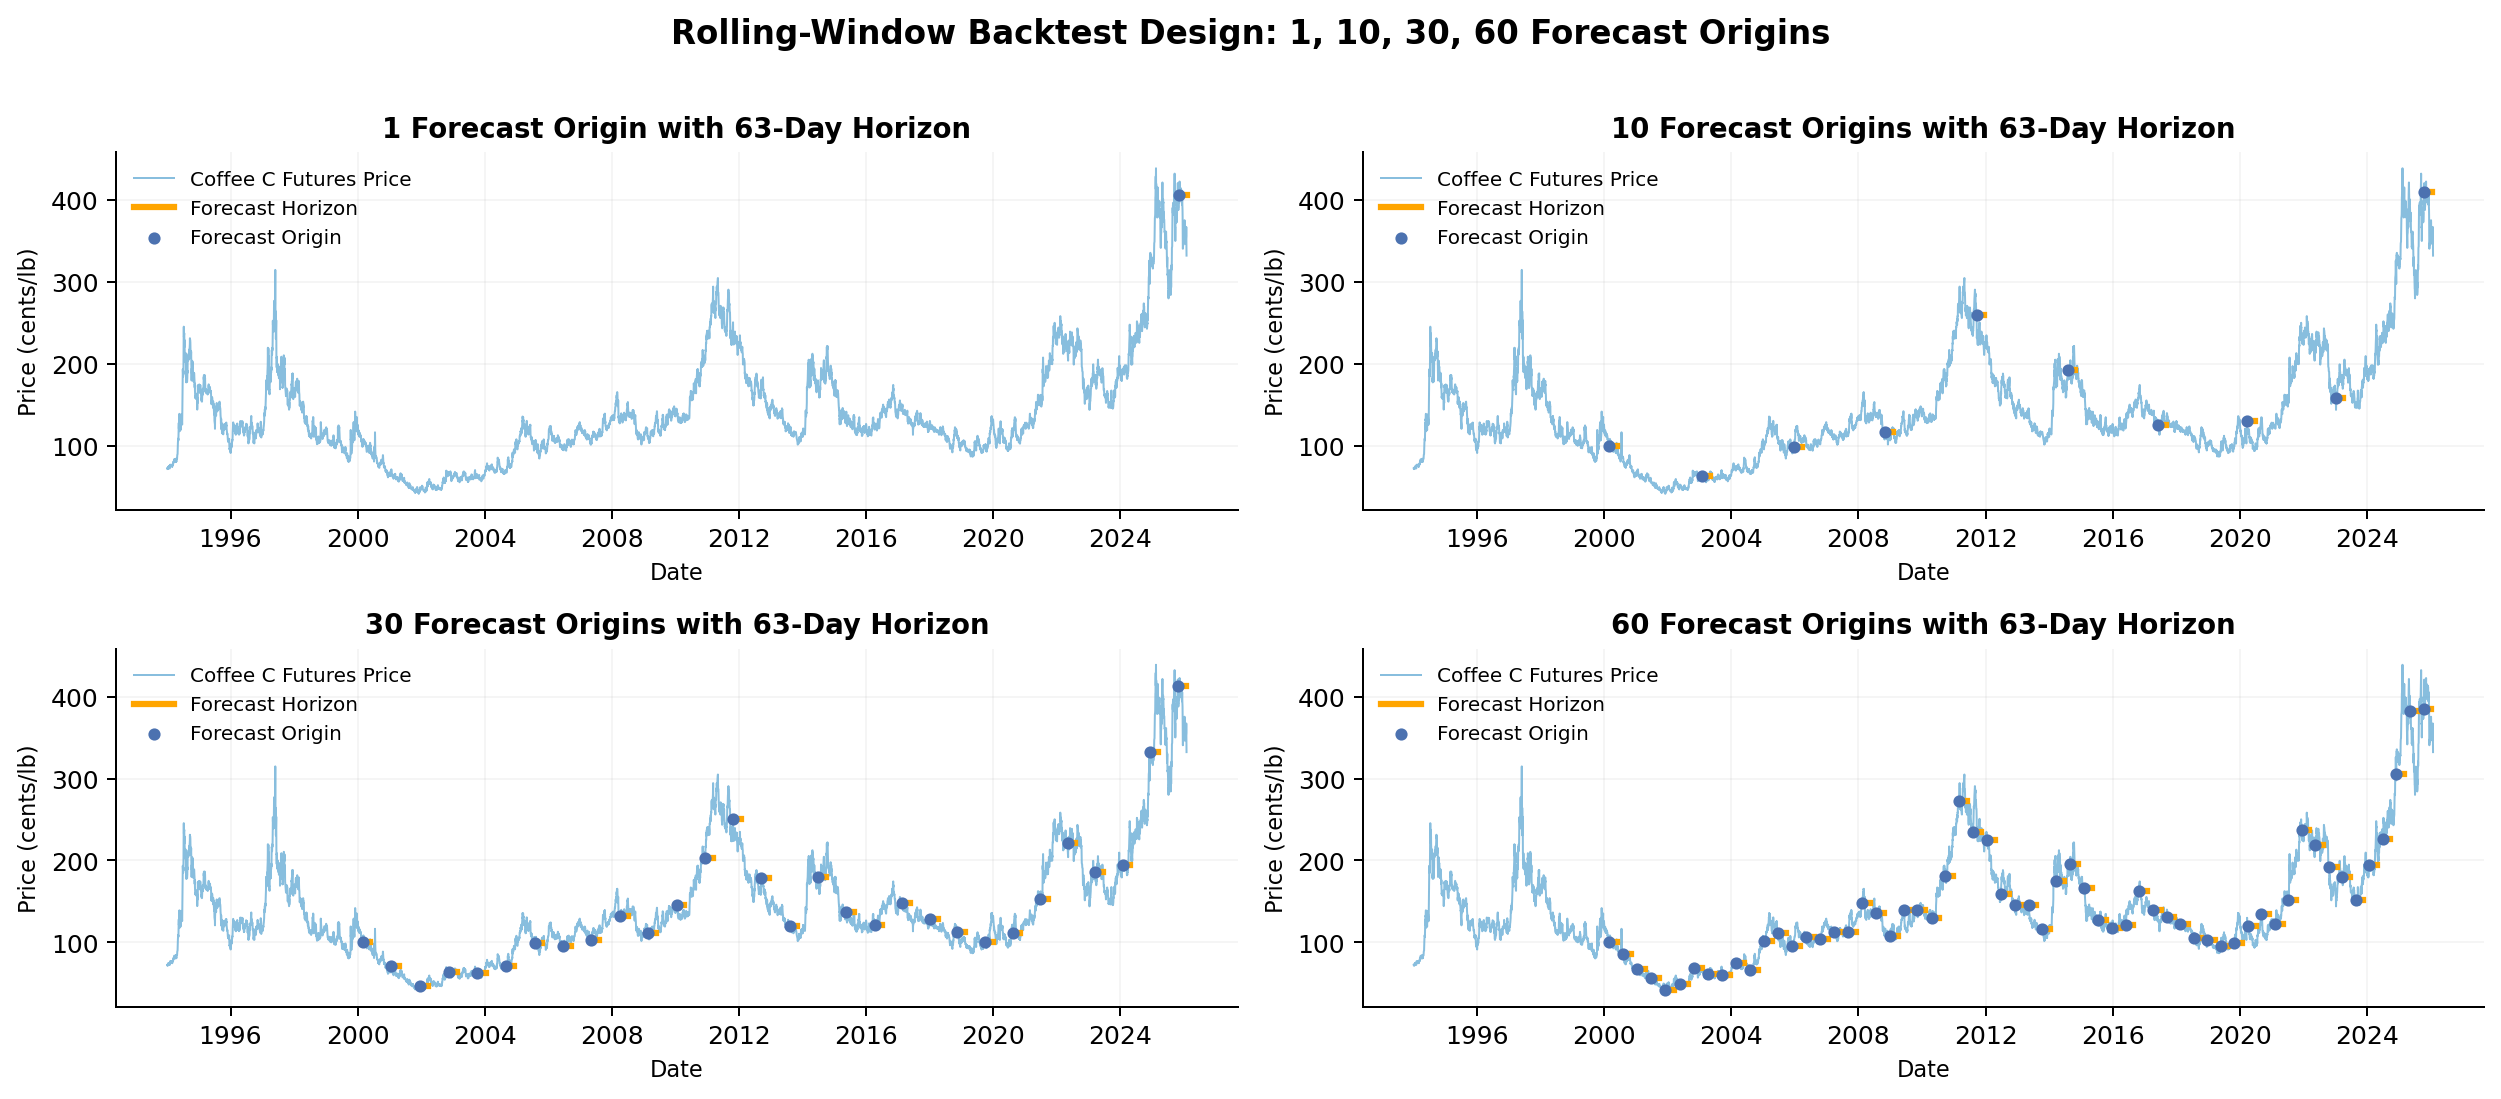

In [33]:
_ = plot_forecast_origin_coverage(
    df,
    scales=SCALES,
    save_path=FIG_DIR / "forecast_origin_coverage.png",
)
plt.show()

## 6. Run the multi-scale backtest

`run_multi_scale_backtest` loops every (scale, model) combination and returns:

- `summary` &mdash; long-format DataFrame with one row per (origin, model, scale)
- `step_errors` &mdash; nested dict: `step_errors[scale][model_name]` is an
  ndarray of shape `(num_origins, horizon)` with absolute errors at each step

Runtime is dominated by the 60-origin scale (60 fits per model). Expect
30-60 minutes on CPU depending on the Granite-TTM hardware path.


In [34]:
summary, step_errors = run_multi_scale_backtest(
    df=df,
    models=models,
    scales=SCALES,
    context_len=CONTEXT_LEN,
    horizon=HORIZON,
    verbose=True,
)
print(f"\nTotal rows in summary: {len(summary)}")
summary.head()


Running 1 forecast origin(s)...
  ✓ Naive
  ✓ RWD
  ✓ Theta
  ✓ ETS
  ✓ ARIMA
  ✓ GARCH
  ✓ Prophet
  ✓ Ridge
  ✓ RF
  ✓ Granite-TTM

Running 10 forecast origin(s)...
  ✓ Naive
  ✓ RWD
  ✓ Theta
  ✓ ETS
  ✓ ARIMA
  ✓ GARCH
  ✓ Prophet
  ✓ Ridge
  ✓ RF
  ✓ Granite-TTM

Running 30 forecast origin(s)...
  ✓ Naive
  ✓ RWD
  ✓ Theta
  ✓ ETS
  ✓ ARIMA
  ✓ GARCH
  ✓ Prophet
  ✓ Ridge
  ✓ RF
  ✓ Granite-TTM

Running 60 forecast origin(s)...
  ✓ Naive
  ✓ RWD
  ✓ Theta
  ✓ ETS
  ✓ ARIMA
  ✓ GARCH
  ✓ Prophet
  ✓ Ridge
  ✓ RF
  ✓ Granite-TTM

Total rows in summary: 1010


,MAE,RMSE,MAPE,sMAPE,MASE,origin_id,origin_date,model,scale
0,26.038889,29.875577,0.071331,0.068703,7.211687,1,2025-11-03,Naive,1
1,29.230761,35.042854,0.080769,0.076698,8.095703,1,2025-11-03,RWD,1
2,27.325129,31.970789,0.075154,0.071951,7.567922,1,2025-11-03,Theta,1
3,26.038889,29.875575,0.071331,0.068703,7.211687,1,2025-11-03,ETS,1
4,26.044184,29.926982,0.071368,0.068716,7.213154,1,2025-11-03,ARIMA,1


## 7. Export CSVs for downstream notebooks

Both files land in `results/csv/`. Notebook 02 (per-model plots) and
notebook 03 (statistical tests) read these directly and do not need
to re-run the backtest.


In [35]:
summary_path = CSV_DIR / "summary_all_scales.csv"
summary.to_csv(summary_path, index=False)
print(f"Saved: {summary_path.relative_to(REPO_ROOT)}")

step_errors_df = step_errors_to_long_df(step_errors)
step_errors_path = CSV_DIR / "step_errors_all_scales.csv"
step_errors_df.to_csv(step_errors_path, index=False)
print(f"Saved: {step_errors_path.relative_to(REPO_ROOT)}  ({len(step_errors_df)} rows)")

Saved: results/csv/summary_all_scales.csv
Saved: results/csv/step_errors_all_scales.csv  (63630 rows)


## 8. Quick sanity check: 60-origin leaderboard

A preview of the final table. The rigorous model comparison &mdash;
Diebold-Mariano tests and the Model Confidence Set &mdash; comes in
notebook 03; here we just confirm the numbers look sensible.


In [36]:
leaderboard = (
    summary[summary["scale"] == 60]
    .groupby("model")[["MAE", "RMSE", "MASE", "sMAPE"]]
    .mean()
    .sort_values("MAE")
)
print("60-origin mean metrics (sorted by MAE):")
leaderboard.round(3)

60-origin mean metrics (sorted by MAE):


,MAE,RMSE,MASE,sMAPE
model,,,,
RWD,12.789,14.841,6.103,0.083
ETS,12.819,14.893,6.110,0.085
Theta,12.862,14.934,6.133,0.085
Naive,12.909,14.986,6.147,0.085
RF,13.132,15.188,6.282,0.087
ARIMA,13.239,15.385,6.283,0.085
GARCH,13.505,15.740,6.504,0.090
Granite-TTM,13.842,16.089,6.551,0.092
Ridge,14.682,17.160,6.872,0.101


Rigorous statistical comparison of these differences appears in notebook 03.

---

**Next notebook:** `02_per_model_plots.ipynb` &mdash; turns the benchmark
CSVs into aggregate pictures: MAE convergence across scales
(1 &rarr; 10 &rarr; 30 &rarr; 60), the 60-origin distribution, and a
per-origin deep dive of IBM Granite TTM vs. RWD.
